In [1]:
# Experiment: Polynomial Regression on Auto MPG Dataset
# Prediction of MPG using Engine Displacement
# =====================================================

# Step 1: Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load Auto MPG dataset
url = "http://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df = pd.read_csv(url)

# Display first five rows
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [3]:
# Separate input and output
X = df[['displacement']]
y = df['mpg']

#Check missing value
print("Missing values in", X.isnull().sum())
print("Missing values in mpg", y.isnull().sum())

Missing values in displacement    0
dtype: int64
Missing values in mpg 0


In [4]:
# Remoce rows containing missing values
data = df[['displacement', 'mpg']].dropna()

# Update input and output
X = data[['displacement']]
y = data['mpg']

# Display the selected data
print("Feature")
print(X.head())

print("\nTarget")
print(y.head())

Feature
   displacement
0         307.0
1         350.0
2         318.0
3         304.0
4         302.0

Target
0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64


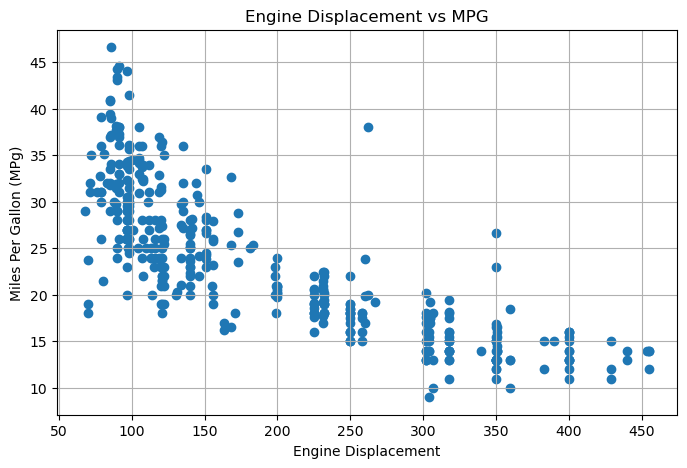

In [5]:
plt.figure(figsize=(8,5))
plt.scatter(X,y)

plt.xlabel("Engine Displacement")
plt.ylabel("Miles Per Gallon (MPg)")
plt.title("Engine Displacement vs MPG")

plt.grid(True)
plt.show()

In [6]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size = 0.2,
    random_state = 42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 318
Testing samples: 80


In [7]:
# Create Linear Regression
linear_model = LinearRegression()

#Train the model
linear_model.fit(X_train, y_train)

# Predict on test data
y_pred_linear = linear_model.predict(X_test)

In [8]:
# Calculate MSE
mse_linear = mean_squared_error(y_test, y_pred_linear)

# Calculate R-squared
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("-------------------------")
print("MSE:", mse_linear)
print("R-squared:", r2_linear)

Linear Regression Results
-------------------------
MSE: 18.102543998358946
R-squared: 0.6633114869465595


In [9]:
# Store results
results = []

# Store polynomial models fro plotting
polynomial_models = {}

# Add Linear Regression Results
results.append({
    'Model': 'Linear Regression',
    'Degree': 1,
    'MSE': mse_linear,
    'R-squared': r2_linear
})

In [10]:
# Try polynomial features
for degree in range(2,6):
    # Create polynomial features
    poly = PolynomialFeatures(degree=degree)

    # Transform training and testing data
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Create Linear Regression model
    poly_model = LinearRegression()

    #Train polynomial regression model
    poly_model.fit(X_train_poly, y_train)

    # Make predictions
    y_pred_poly = poly_model.predict(X_test_poly)

    #Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred_poly)
    r2 = r2_score(y_test, y_pred_poly)

    # Store results
    results.append({
        'Model': 'Polynomial Regression',
        'Degree': degree,
        'MSE': mse,
        'R-squared': r2
    })

    # Store model and polynomial transformer
    polynomial_models[degree] = {
        'poly': poly,
        'model': poly_model
    }

In [12]:
# Convert results into DataFrame
results_df = pd.DataFrame(results)

# Display results
results_df

,Model,Degree,MSE,R-squared
0,Linear Regression,1,18.102544,0.663311
1,Polynomial Regression,2,15.107354,0.719019
2,Polynomial Regression,3,14.943632,0.722064
3,Polynomial Regression,4,14.961487,0.721732
4,Polynomial Regression,5,15.230896,0.716721


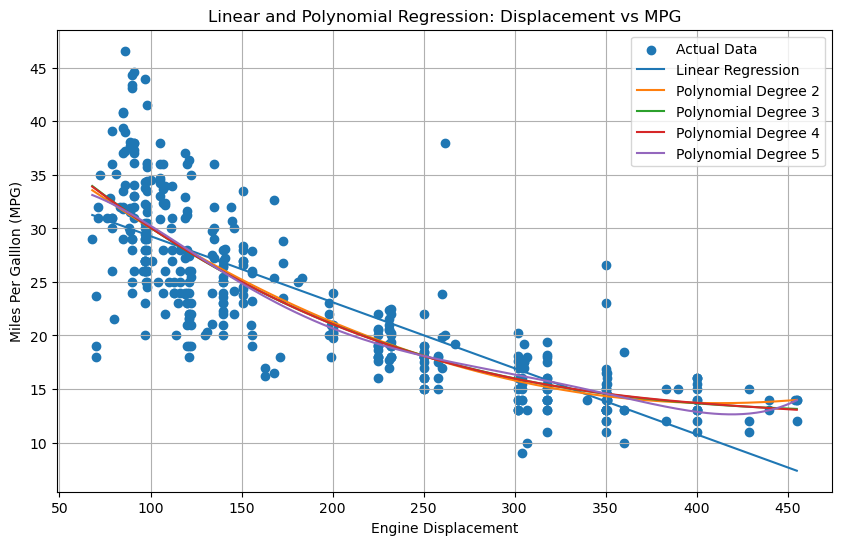

In [25]:
# Create smooth X values for plotting
X_plot = pd.DataFrame({
    'displacement': np.linspace(
        X['displacement'].min(),
        X['displacement'].max(),
        300
    )
})

# Create figure
plt.figure(figsize=(10,6))

# Plot actual data
plt.scatter(
    X['displacement'],
    y,
    label = 'Actual Data'
)


# --------------------------

y_plot_linear = linear_model.predict(X_plot)

plt.plot(
    X_plot['displacement'],
    y_plot_linear,
    label = 'Linear Regression'
)

# Plot ploynomial regression
for degree in range(2,6):
    # Retrieve stored transformer and model
    poly = polynomial_models[degree]['poly']
    poly_model = polynomial_models[degree]['model']

    # Transform smooth X values
    X_plot_poly = poly.transform(X_plot)

    # predict
    y_plot_poly = poly_model.predict(X_plot_poly)

    # Plot curve
    plt.plot(
        X_plot['displacement'],
        y_plot_poly,
        label = f"Polynomial Degree {degree}"
    )

# Plot formatting
#----------------

plt.xlabel('Engine Displacement')
plt.ylabel('Miles Per Galllon (MPG)')

plt.title(
    'Linear and Polynomial Regression: Displacement vs MPG'
)
plt.legend()
plt.grid(True)
plt.show()

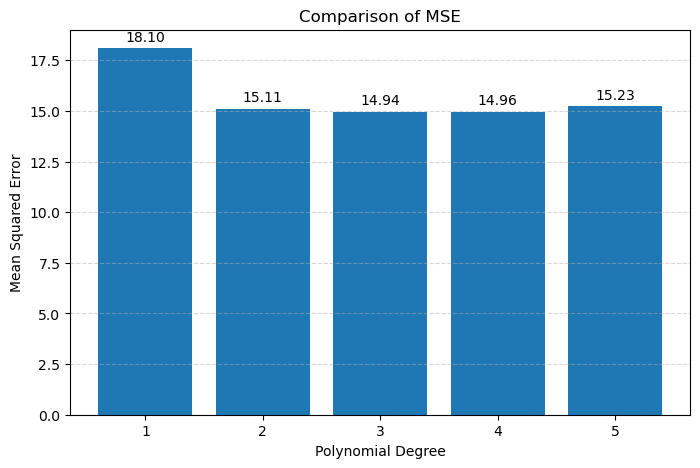

In [28]:
plt.figure(figsize=(8,5))
bars = plt.bar(
    results_df['Degree'].astype(str),
    results_df['MSE']
)

# Add lables above bars
plt.bar_label(bars, fmt='%.2f', padding=3)

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Comparison of MSE")
plt.grid(axis='y', linestyle = '--', alpha = 0.5)
plt.show()

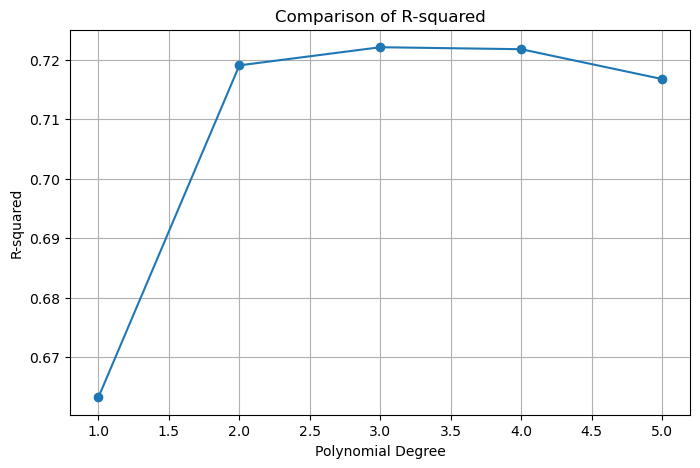

In [31]:
plt.figure(figsize=(8,5))
plt.plot(
    results_df['Degree'],
    results_df['R-squared'],
    marker='o'
)

plt.xlabel("Polynomial Degree")
plt.ylabel("R-squared")
plt.title("Comparison of R-squared")
plt.grid(True)
plt.show()